In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from multiprocessing import Pool
from concurrent.futures import ProcessPoolExecutor
import concurrent.futures
import pandas as pd
from tqdm import tqdm
from scipy.optimize import minimize, basinhopping

plt.rcParams['text.latex.preamble'] = r"\usepackage{amsmath}"
plt.rc('font',**{'family':'sans-serif','sans-serif':['Helvetica']})
plt.rc('text',usetex=True)

import julia
from julia import Main
from julia import Distributed
Main.eval("using QuadGK")

In [2]:
Main.eval('using Distributed')
Main.eval('addprocs(7)') 

array([2, 3, 4, 5, 6, 7, 8], dtype=int64)

In [16]:
Main.include("strong coupling\\constants.jl")
Main.include("strong coupling\\alpha_s.jl")
Main.include("anomalous dim\\cusp\\cusp.jl")
Main.include("anomalous dim\\non-cusp\\gammaH.jl")
Main.include("anomalous dim\\non-cusp\\gammaB.jl")
Main.include("anomalous dim\\non-cusp\\gammaS.jl")
Main.include("anomalous dim\\non-cusp\\gammav.jl")
Main.include("hard\\hard.jl")
Main.include("jet\\jet.jl")
Main.include("soft\\soft.jl")
Main.include("sigma.jl")
Main.include("error.jl")
Main.include("fixed order\\perturbation.jl")
Main.include("fixed order\\SCET.jl")
Main.include("fixed order\\non-singular.jl")
Main.include("fit.jl")
Main.include("NP.jl")

<PyCall.jlwrap NP>

Range Choice

In [17]:
χ_lower = 120
χ_upper = 180

Read Data

In [18]:
df_OPAL = pd.read_csv("data/OPAL.csv")
truncated_OPAL = df_OPAL[(df_OPAL["CHI"] <= χ_upper) & (df_OPAL["CHI"] >= χ_lower)]

χ_OPAL = np.array(truncated_OPAL["CHI"])
EEC_OPAL = np.array(truncated_OPAL["EEC"])
STAT_OPAL = np.array(truncated_OPAL["STAT"])

print(χ_OPAL.size)

33


Define Minimization

In [19]:
import sys
def objective(params, xlist, ylist, errlist):

    αs = params[0]
    length = len(xlist)
    parameters = params[1:]

    residuals = (Main.model(xlist=xlist, αs=αs, parameters=parameters) - ylist)/errlist #
    chi2 = np.sum(np.square(residuals))

    return chi2/length

class ProgressCallback:
    def __init__(self, x_data, y_data, y_err):
        self.x_data = x_data
        self.y_data = y_data
        self.y_err = y_err
        self.iteration = 0
        #self.pbar = tqdm(total=200)

    def __call__(self, params):
        self.iteration += 1
        chi2_bydof = objective(params, self.x_data, self.y_data, self.y_err)
        print(f"Iteration: {self.iteration}, Params: {params}, Chi2/dof: {chi2_bydof}")
        sys.stdout.flush()
        #self.pbar.update()

class MyBounds:
    def __init__(self, xmax, xmin):
        self.xmax = np.array(xmax)
        self.xmin = np.array(xmin)

    def __call__(self, **kwargs):
        x = kwargs["x_new"]
        tmax = bool(np.all(x <= self.xmax))
        tmin = bool(np.all(x >= self.xmin))
        return tmax and tmin

Test

In [9]:
objective([0.118,1.0,0.0], χ_OPAL, EEC_OPAL, STAT_OPAL)

13.213705767699361

Global

In [13]:
bounds = [[0.0  , 3.0]
         ,[-1.0 , 1.0]
         ,[-1.0 , 1.0]
        ]

n_points = 5
n_parameters = len(bounds)

points = [np.linspace(bound[0], bound[1], n_points) for bound in bounds]
mesh = np.meshgrid(*points, indexing='ij')
params = [list(coord) for coord in zip(*(x.ravel() for x in mesh))]
print(params)

[[0.0, -1.0, -1.0], [0.0, -1.0, -0.5], [0.0, -1.0, 0.0], [0.0, -1.0, 0.5], [0.0, -1.0, 1.0], [0.0, -0.5, -1.0], [0.0, -0.5, -0.5], [0.0, -0.5, 0.0], [0.0, -0.5, 0.5], [0.0, -0.5, 1.0], [0.0, 0.0, -1.0], [0.0, 0.0, -0.5], [0.0, 0.0, 0.0], [0.0, 0.0, 0.5], [0.0, 0.0, 1.0], [0.0, 0.5, -1.0], [0.0, 0.5, -0.5], [0.0, 0.5, 0.0], [0.0, 0.5, 0.5], [0.0, 0.5, 1.0], [0.0, 1.0, -1.0], [0.0, 1.0, -0.5], [0.0, 1.0, 0.0], [0.0, 1.0, 0.5], [0.0, 1.0, 1.0], [0.75, -1.0, -1.0], [0.75, -1.0, -0.5], [0.75, -1.0, 0.0], [0.75, -1.0, 0.5], [0.75, -1.0, 1.0], [0.75, -0.5, -1.0], [0.75, -0.5, -0.5], [0.75, -0.5, 0.0], [0.75, -0.5, 0.5], [0.75, -0.5, 1.0], [0.75, 0.0, -1.0], [0.75, 0.0, -0.5], [0.75, 0.0, 0.0], [0.75, 0.0, 0.5], [0.75, 0.0, 1.0], [0.75, 0.5, -1.0], [0.75, 0.5, -0.5], [0.75, 0.5, 0.0], [0.75, 0.5, 0.5], [0.75, 0.5, 1.0], [0.75, 1.0, -1.0], [0.75, 1.0, -0.5], [0.75, 1.0, 0.0], [0.75, 1.0, 0.5], [0.75, 1.0, 1.0], [1.5, -1.0, -1.0], [1.5, -1.0, -0.5], [1.5, -1.0, 0.0], [1.5, -1.0, 0.5], [1.5, -1.0

In [14]:
chi2_list = []
for parameters in tqdm(params):
    parameters.insert(0,0.118)
    chi2_list.append(objective(parameters, χ_OPAL, EEC_OPAL, STAT_OPAL))
min_chi2 = min(chi2_list)
best_params = params[chi2_list.index(min_chi2)]
print("min_chi2/dof",min_chi2,"best_params",best_params)

100%|██████████| 125/125 [04:22<00:00,  2.10s/it]

min_chi2/dof 4.5422491377306535 best_params [0.118, 1.5, -0.5, 0.0]


Local then hopping

In [7]:
initial_params = [0.118,0.0,0.0,0.0] #best_params #[0.118, 2.0]
bounds = [[0.110  , 0.126]
          ,[0.0   , 10.0]
          ,[-10.0 , 10.0]
          ,[-10.0 , 10.0]           
        ]
bounds_T = [list(t) for t in zip(*bounds)]

progress_callback = ProgressCallback(χ_OPAL, EEC_OPAL, STAT_OPAL)

minimizer_kwargs = {
    "method": "L-BFGS-B",
    "bounds": bounds,
    "args": (χ_OPAL, EEC_OPAL, STAT_OPAL),
    "options": {'maxiter': 100, 'disp': True},
    "callback": progress_callback
}

result = basinhopping(
    objective,
    initial_params,
    minimizer_kwargs=minimizer_kwargs,
    niter=1,
    accept_test=MyBounds(xmax=bounds_T[1],xmin=bounds_T[0])
)

optimal_params = result.x
print(f"Optimal parameters: {optimal_params}")

Iteration: 1, Params: [ 0.11818518  0.23147579 -0.23147579 -0.23147579], Chi2/dof: 7.777132232520924
Iteration: 2, Params: [ 0.11869314  0.18228183 -0.18228327 -0.18226562], Chi2/dof: 7.0700138466966145
Iteration: 3, Params: [ 0.11992417  0.11797095 -0.1179751  -0.11791498], Chi2/dof: 6.599708679414939
Iteration: 4, Params: [ 0.12091781  0.09311139 -0.09310856 -0.09299439], Chi2/dof: 6.435213510739982
Iteration: 5, Params: [ 0.12112985  0.08003005 -0.08002553 -0.07989797], Chi2/dof: 6.422553517261685
Iteration: 6, Params: [ 0.12112335  0.08013313 -0.08011785 -0.07996092], Chi2/dof: 6.422376460847449
Iteration: 7, Params: [ 0.12108378  0.08096176 -0.08081325 -0.08029149], Chi2/dof: 6.4208322686008685
Iteration: 8, Params: [ 0.1210352   0.08245593 -0.08201374 -0.0806866 ], Chi2/dof: 6.418010878828726
Iteration: 9, Params: [ 0.12092831  0.08698766 -0.08555948 -0.08152645], Chi2/dof: 6.409384771310589
Iteration: 10, Params: [ 0.12072865  0.09817266 -0.09416166 -0.08303794], Chi2/dof: 6.388

In [9]:
Main.eval('rmprocs(workers())')

<PyCall.jlwrap Task (runnable) @0x0000018f9ae645e0>

Plot

In [8]:
χ_OPAL = np.array(df_OPAL["CHI"])
EEC_OPAL = np.array(df_OPAL["EEC"])
STAT_OPAL = np.array(df_OPAL["STAT"])

In [20]:
xlist = np.pi/180*np.linspace(χ_lower,179.9,100)
length=len(xlist)

αs=0.126#optimal_params[0]
parameters=[1.65]#optimal_params[1:]

v_2 = Main.sigma_fast(Q=91.2, χ_list=xlist, μ_ini=91.1876, αs_ini=αs, nf=5, order=2, parameters=parameters)

non_singular_2 = []

for x in xlist:
    non_singular_2.append(Main.non_singular_sigma_χ(χ=x, Q=91.2, μ_ini=91.1876, αs_ini=0.12434569, nf=5, order=2))

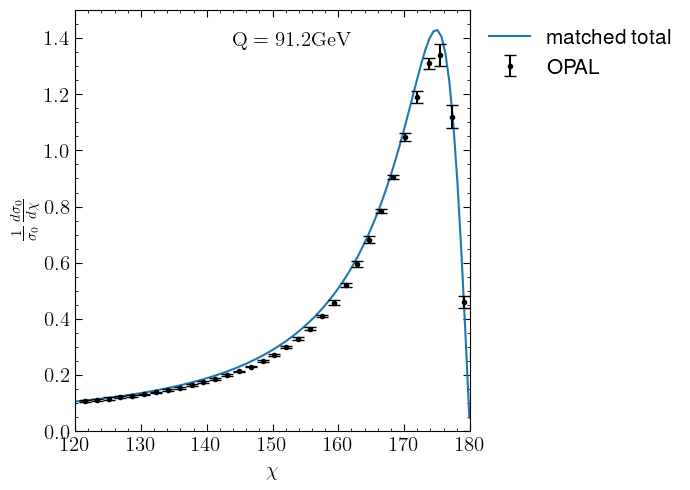

In [21]:
fig, ax1 = plt.subplots(1, 1, figsize=(7, 5)) 

sizeOfFont = 15
sizeOfTick = 15

ax1.plot(xlist*180/np.pi, v_2+non_singular_2, label="matched total")
ax1.errorbar(χ_OPAL, EEC_OPAL, yerr=STAT_OPAL, fmt='o',label="OPAL",color="black", capsize=4,markersize=3)

ax1.set_xlabel(r"\rm $\chi$",fontsize=sizeOfFont)
ax1.set_ylabel(r"\rm $\frac{1}{\sigma_0} \frac{d \sigma_0}{d \chi}$",fontsize=sizeOfFont)
ax1.legend()

ax1.minorticks_on()
ax1.tick_params(axis="both",direction="in", length=5,labelsize = sizeOfTick, top=True, right=True)
ax1.tick_params(axis="both",which = "minor",direction="in", length=2.5,labelsize = sizeOfTick, top=True, right=True)
ax1.legend(frameon = False,fontsize = sizeOfTick, bbox_to_anchor=(1, 1))

props = dict(boxstyle='round', facecolor='white', alpha=0)
ax1.text(0.4, 0.95,  r"\rm $ \mathrm{Q}= 91.2 \mathrm{GeV} $", transform=ax1.transAxes, fontsize=sizeOfFont,
verticalalignment='top', bbox=props)

plt.ylim(0,1.5)
plt.xlim(120,180)

plt.tight_layout()  
plt.show()

In [ ]:
initial_params = [0.118, 2.0]
bounds = [[0.113  , 0.123]
          ,[0.0   , 10.0]]
#          ,[-10.0 , 10.0]
#          ,[-10.0 , 10.0]           
#        ]

progress_callback = ProgressCallback(χ_OPAL, EEC_OPAL, STAT_OPAL)

result = minimize(
    fun=objective,
    x0=initial_params,
    args=(χ_OPAL, EEC_OPAL, STAT_OPAL),
    method='L-BFGS-B',
    bounds=bounds,
    options={'maxiter': 100, 'disp': True},
    #tol = 0.00001,
    callback=progress_callback
)

optimal_params = result.x
print(f"Optimal parameters: {optimal_params}")